# 04 - Quantile regression e feature di rotta

Due modifiche al modello finale della Sezione 9 di `01_eda.ipynb` (XGBoost asimmetrico tunato,
MAE 10.00gg / 4.4% di anticipi):

1. **Quantile regression** (`reg:quantileerror`) al posto della MSE asimmetrica. L'obiettivo di
   business "al massimo il 5% di previsioni anticipate" *e'* il 95esimo percentile condizionale:
   con la loss pinball diventa un iperparametro con significato diretto (`quantile_alpha`),
   invece di una `penalty` opaca da tarare a griglia.
2. **Feature di rotta** (`seller_state -> customer_state`) con target encoding causale, per
   catturare l'effetto RJ/PA/PE emerso nel notebook 03 e che la sola distanza in linea d'aria
   non spiega.

L'obiettivo non e' scambiare MAE per anticipi (quello lo sappiamo gia' fare con la `penalty`),
ma **spostare la frontiera**: meno MAE *a parita'* di quota di anticipi.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

from src import features, data_loader

pd.options.display.float_format = '{:,.2f}'.format

## 1. Le feature di rotta

`route_history_features()` (in `src/features.py`) calcola per ogni ordine la **media dei giorni
di consegna gia' osservati sulla stessa rotta** stato-venditore -> stato-cliente.

Il punto delicato e' la causalita'. Non basta ordinare per data di acquisto: un ordine
acquistato prima ma consegnato dopo non e' ancora osservabile al checkout. La media usa quindi
solo consegne **concluse** prima dell'acquisto corrente (`delivered_ts < purchase_ts`).

Tre colonne:
- `route_prior_days` - media dei giorni sulla rotta;
- `route_prior_n` - quante consegne la compongono (affidabilita' della media);
- `cust_state_prior_days` - stesso calcolo aggregato al solo stato cliente, ripiego per le rotte rare.

Il parametro `window_days` decide se la media e' **espandente** (tutta la storia) o su
**finestra mobile**. Sezione 3: e' la scelta che ribalta il risultato.

In [2]:
raw = data_loader.load_all_raw()

route_60 = features.route_history_features(raw, window_days=60)
route_exp = features.route_history_features(raw, window_days=None)

print('finestra 60gg :', route_60['route_prior_days'].describe()[['mean', 'std']].to_dict())
print('espandente    :', route_exp['route_prior_days'].describe()[['mean', 'std']].to_dict())
print(f"\nquota di ordini senza storico sulla rotta (60gg): {route_60['route_prior_days'].isna().mean():.1%}")
route_60.head()

finestra 60gg : {'mean': 12.678520531164354, 'std': 5.344868045995855}
espandente    : {'mean': 12.426074309881447, 'std': 4.057398854399498}

quota di ordini senza storico sulla rotta (60gg): 1.4%


,order_id,route_prior_days,route_prior_n,cust_state_prior_days
0,e481f51cbdc54678b7cc49136f2d6af7,7.01,2346,7.77
1,53cdb2fc8bc7dce0b6741e2150273451,19.70,297,19.54
2,47770eb9100c2d0c44946d9cf07ec65d,11.96,156,12.22
3,949d5b44dbf5de918fe9c16f97b45f8a,16.04,5,19.31
4,ad21c59c0840e6cb83a9ceb5573f8159,9.09,3731,10.25


### Perche' la finestra conta: la feature deve inseguire il trend

In `01_eda.ipynb` (Sezione 8) abbiamo visto che i tempi di consegna **calano** da ~17gg a inizio
2018 a ~8gg ad agosto. Una media espandente incorpora anche il 2016-17 e resta ancorata in alto;
una finestra mobile segue il regime corrente.

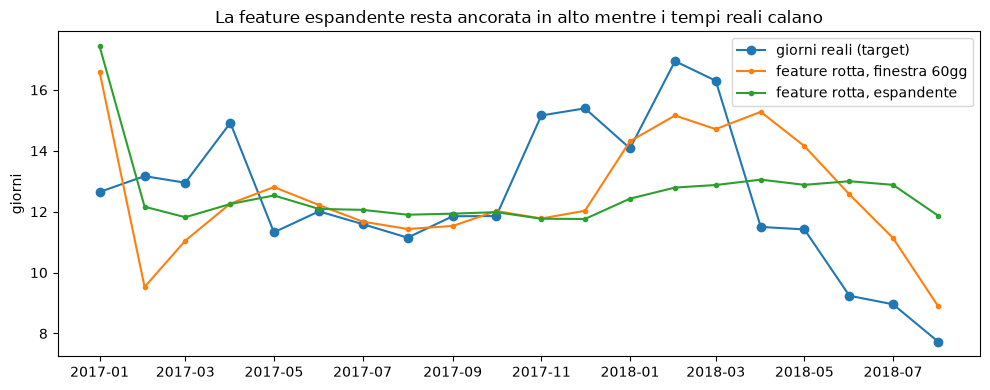

In [3]:
orders = raw['orders']
delivered = orders[(orders['order_status'] == 'delivered')
                    & orders['order_delivered_customer_date'].notna()].copy()
delivered['delivery_days'] = ((delivered['order_delivered_customer_date']
                                - delivered['order_purchase_timestamp']).dt.total_seconds() / 86400.0)
delivered['mese'] = delivered['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()

cmp_df = delivered[['order_id', 'mese', 'delivery_days']].merge(
    route_60[['order_id', 'route_prior_days']].rename(columns={'route_prior_days': 'rotta 60gg'}),
    on='order_id', how='left').merge(
    route_exp[['order_id', 'route_prior_days']].rename(columns={'route_prior_days': 'rotta espandente'}),
    on='order_id', how='left')
monthly = cmp_df.groupby('mese')[['delivery_days', 'rotta 60gg', 'rotta espandente']].mean()
monthly = monthly[monthly.index >= '2017-01-01']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly['delivery_days'], marker='o', label='giorni reali (target)')
ax.plot(monthly.index, monthly['rotta 60gg'], marker='.', label='feature rotta, finestra 60gg')
ax.plot(monthly.index, monthly['rotta espandente'], marker='.', label='feature rotta, espandente')
ax.set_ylabel('giorni')
ax.set_title('La feature espandente resta ancorata in alto mentre i tempi reali calano')
ax.legend()
fig.tight_layout()
plt.show()

## 2. Dati, split e modello di riferimento

Stesso split temporale di `01_eda.ipynb`: 80% piu' vecchio -> train (di cui l'85% come `fit` e il
15% finale come `calib`), 20% piu' recente -> test. Stessa architettura tunata nella Sezione 9,
cosi' l'unica cosa che cambia e' l'obiettivo e il set di feature.

In [4]:
BASE = ['distance_km_mean', 'total_freight', 'distance_km_max',
        'customer_state', 'approval_hours', 'total_weight_g', 'main_category']
ROUTE_EXTRA = ['route_prior_days', 'route_prior_n', 'cust_state_prior_days']
CAT = ['customer_state', 'main_category']
ARCH = dict(subsample=0.7, n_estimators=300, min_child_weight=3, max_depth=5,
            learning_rate=0.013707256063767185, colsample_bytree=0.6)

table = data_loader.build_order_table()
for f in (features.distance_features(raw), features.weight_volume_features(raw),
          features.payment_approval_features(raw), features.category_features(raw)):
    table = table.merge(f, on='order_id', how='left')


def build_frame(window_days):
    """Tabella modello con le feature di rotta calcolate sulla finestra scelta."""
    rt = (route_60 if window_days == 60 else
          route_exp if window_days is None else
          features.route_history_features(raw, window_days=window_days))
    df = table.merge(rt, on='order_id', how='left')
    for c in CAT:
        df[c] = df[c].astype('category')
    return df.sort_values('purchase_date').reset_index(drop=True)


def split_parts(df):
    s = int(len(df) * 0.8)
    train, test = df.iloc[:s], df.iloc[s:]
    return train.iloc[:int(len(train) * 0.85)], train.iloc[int(len(train) * 0.85):], test


def evaluate(model, cols, parts):
    fit_df, calib_df, test = parts
    model.fit(fit_df[cols], fit_df['delivery_days'].to_numpy())
    ec = model.predict(calib_df[cols]) - calib_df['delivery_days'].to_numpy()
    et = model.predict(test[cols]) - test['delivery_days'].to_numpy()
    return dict(MAE_calib=np.abs(ec).mean(), early_calib=(ec < 0).mean() * 100,
                MAE_test=np.abs(et).mean(), early_test=(et < 0).mean() * 100)


parts_60 = split_parts(build_frame(60))
print(f'fit {len(parts_60[0]):,} | calib {len(parts_60[1]):,} | test {len(parts_60[2]):,}')

test_ref = parts_60[2]
base_err = test_ref['estimated_days'].to_numpy() - test_ref['delivery_days'].to_numpy()
print(f'Baseline ufficiale: MAE {np.abs(base_err).mean():.2f}gg, anticipi {(base_err < 0).mean():.1%}')

fit 65,599 | calib 11,577 | test 19,294
Baseline ufficiale: MAE 13.13gg, anticipi 5.3%


## 3. Esperimento: obiettivo x finestra della rotta

Facciamo variare tre cose e guardiamo la frontiera MAE / quota anticipi sul test:
- **obiettivo**: MSE asimmetrica (`penalty`) vs quantile regression (`quantile_alpha`);
- **feature di rotta**: assenti, espandenti, o su finestra mobile (180/90/60/45/30/21 giorni).

In [5]:
def make_asym(penalty):
    def obj(y_true, y_pred):
        residual = y_pred - y_true
        w = np.where(residual < 0, penalty, 1.0)
        return 2 * w * residual, 2 * w
    return obj


windows = [None, 180, 90, 60, 45, 30, 21]
frames = {w: build_frame(w) for w in windows}

rows = []
configs = ([('(nessuna)', BASE, frames[60])]
           + [('espandente' if w is None else f'{w}gg', BASE + ROUTE_EXTRA, frames[w]) for w in windows])

for rotta, cols, df in configs:
    parts = split_parts(df)
    for p in [4.0, 5.0, 6.0]:
        m = XGBRegressor(objective=make_asym(p), enable_categorical=True,
                         tree_method='hist', random_state=42, **ARCH)
        rows.append(dict(rotta=rotta, obiettivo='asym MSE', param=p, **evaluate(m, cols, parts)))
    for a in [0.75, 0.78, 0.80, 0.82, 0.85]:
        m = XGBRegressor(objective='reg:quantileerror', quantile_alpha=a, enable_categorical=True,
                         tree_method='hist', random_state=42, **ARCH)
        rows.append(dict(rotta=rotta, obiettivo='quantile', param=a, **evaluate(m, cols, parts)))

res = pd.DataFrame(rows)
print(f'{len(res)} configurazioni valutate')
res.pivot_table(index='rotta', columns=['obiettivo', 'param'], values='MAE_test').round(2)

64 configurazioni valutate


obiettivo  asym MSE             quantile                       
param          4.00  5.00  6.00     0.75 0.78  0.80  0.82  0.85
rotta                                                          
(nessuna)      9.28 10.00 10.61     8.06 8.90  9.57 10.34 11.71
180gg         10.30 11.05 11.64     8.76 9.62 10.30 11.06 12.38
21gg           7.54  8.11  8.65     7.13 7.88  8.44  9.14 10.37
30gg           7.70  8.31  8.79     7.14 7.89  8.47  9.15 10.39
45gg           7.87  8.58  8.99     7.23 7.98  8.56  9.23 10.47
60gg           8.14  8.76  9.32     7.44 8.23  8.84  9.53 10.77
90gg           9.25  9.97 10.49     8.01 8.82  9.47 10.20 11.51
espandente    10.15 10.83 11.39     8.68 9.50 10.22 11.02 12.35

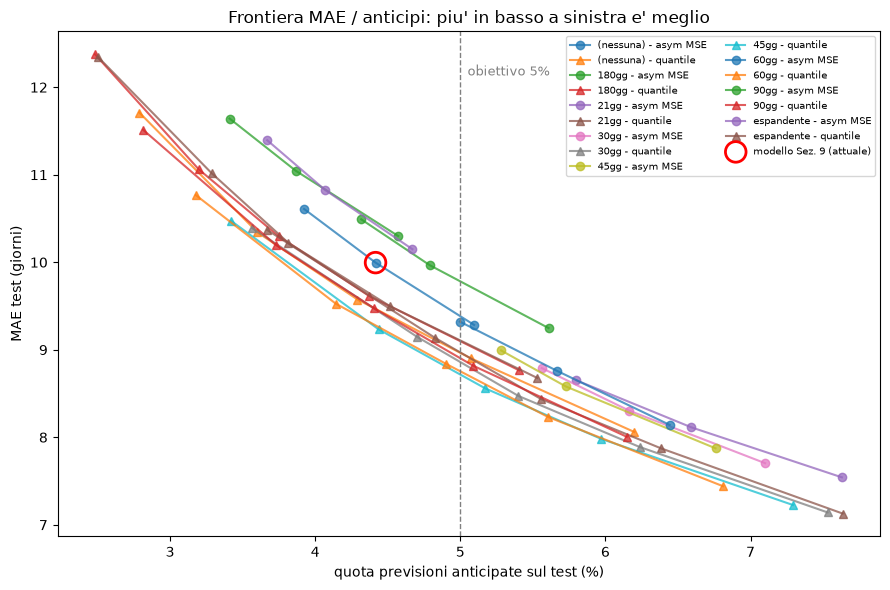

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
markers = {'asym MSE': 'o', 'quantile': '^'}
for (rotta, obiettivo), grp in res.groupby(['rotta', 'obiettivo']):
    grp = grp.sort_values('early_test')
    ax.plot(grp['early_test'], grp['MAE_test'], marker=markers[obiettivo],
            alpha=0.75, label=f'{rotta} - {obiettivo}')

ref = res[(res['rotta'] == '(nessuna)') & (res['obiettivo'] == 'asym MSE') & (res['param'] == 5.0)].iloc[0]
ax.scatter([ref['early_test']], [ref['MAE_test']], s=220, facecolors='none',
           edgecolors='red', linewidths=2, zorder=5, label='modello Sez. 9 (attuale)')
ax.axvline(5.0, color='gray', linestyle='--', linewidth=1)
ax.text(5.05, ax.get_ylim()[1] * 0.97, 'obiettivo 5%', color='gray', fontsize=9, va='top')
ax.set_xlabel('quota previsioni anticipate sul test (%)')
ax.set_ylabel('MAE test (giorni)')
ax.set_title('Frontiera MAE / anticipi: piu\' in basso a sinistra e\' meglio')
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

## 4. Chi vince nella zona utile (anticipi <= 5%)

Il grafico mostra tante curve; quello che conta e' il tratto a sinistra della linea del 5%.

In [7]:
ok = res[res['early_test'] <= 5.0].nsmallest(10, 'MAE_test')
ok[['rotta', 'obiettivo', 'param', 'MAE_test', 'early_test', 'MAE_calib', 'early_calib']].round(2)

,rotta,obiettivo,param,MAE_test,early_test,MAE_calib,early_calib
37,60gg,quantile,0.80,8.84,4.90,8.88,10.84
62,21gg,quantile,0.82,9.14,4.83,8.91,11.20
54,30gg,quantile,0.82,9.15,4.70,9.08,11.05
46,45gg,quantile,0.82,9.23,4.44,9.31,10.22
34,60gg,asym MSE,6.00,9.32,5.00,10.35,7.99
29,90gg,quantile,0.80,9.47,4.41,9.12,10.33
12,espandente,quantile,0.78,9.50,4.51,8.04,12.60
38,60gg,quantile,0.82,9.53,4.14,9.54,9.35
5,(nessuna),quantile,0.80,9.57,4.29,8.15,12.84
20,180gg,quantile,0.78,9.62,4.37,8.21,12.07


In [8]:
best = res[(res['rotta'] == '60gg') & (res['obiettivo'] == 'quantile') & (res['param'] == 0.80)].iloc[0]
dom = res[(res['rotta'] == '90gg') & (res['obiettivo'] == 'quantile') & (res['param'] == 0.80)].iloc[0]

confronto = pd.DataFrame([
    dict(modello='Baseline ufficiale', MAE_test=np.abs(base_err).mean(),
         early_test=(base_err < 0).mean() * 100),
    dict(modello='Sez. 9: asym MSE penalty=5', MAE_test=ref['MAE_test'], early_test=ref['early_test']),
    dict(modello='quantile 0.80 + rotta 90gg', MAE_test=dom['MAE_test'], early_test=dom['early_test']),
    dict(modello='quantile 0.80 + rotta 60gg', MAE_test=best['MAE_test'], early_test=best['early_test']),
]).set_index('modello')
confronto['delta_MAE_vs_Sez9'] = confronto['MAE_test'] - ref['MAE_test']
confronto.round(2)

,MAE_test,early_test,delta_MAE_vs_Sez9
modello,,,
Baseline ufficiale,13.13,5.29,3.14
Sez. 9: asym MSE penalty=5,10.00,4.42,0.00
quantile 0.80 + rotta 90gg,9.47,4.41,-0.52
quantile 0.80 + rotta 60gg,8.84,4.90,-1.16


## 5. Le feature di rotta contano davvero? (e quali)

**Attenzione alla metrica.** Il modello stima il quantile 0.80, non la media. Misurare la
permutation importance con il MAE darebbe risultati con il segno sbagliato: il MAE e' minimizzato
dalla *mediana*, quindi mescolare una feature che alza il livello delle previsioni "migliora" il
MAE pur peggiorando il modello. (Provato: con il MAE, `route_prior_days` risulta *negativa*.)
La metrica corretta e' la **pinball loss allo stesso alpha**, cioe' la loss che il modello sta
davvero ottimizzando.

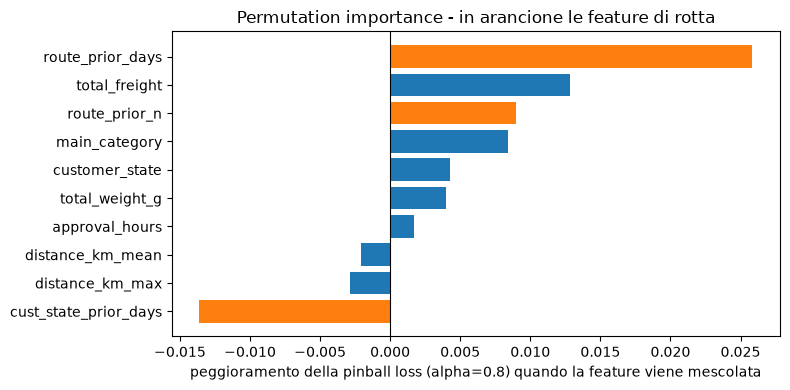

route_prior_days         +0.0258
total_freight            +0.0129
route_prior_n            +0.0090
main_category            +0.0084
customer_state           +0.0043
total_weight_g           +0.0040
approval_hours           +0.0017
distance_km_mean         -0.0021
distance_km_max          -0.0029
cust_state_prior_days    -0.0136
dtype: str

In [9]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, mean_pinball_loss

ALPHA = 0.80
fit_df, calib_df, test = split_parts(frames[60])
cols = BASE + ROUTE_EXTRA
winner = XGBRegressor(objective='reg:quantileerror', quantile_alpha=ALPHA,
                       enable_categorical=True, tree_method='hist', random_state=42, **ARCH)
winner.fit(fit_df[cols], fit_df['delivery_days'].to_numpy())

pinball = make_scorer(mean_pinball_loss, alpha=ALPHA, greater_is_better=False)
perm = permutation_importance(winner, test[cols], test['delivery_days'].to_numpy(),
                              n_repeats=5, random_state=42, scoring=pinball)
imp = pd.Series(perm.importances_mean, index=cols).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['tab:orange' if c in ROUTE_EXTRA else 'tab:blue' for c in imp.index]
ax.barh(imp.index, imp.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel(f'peggioramento della pinball loss (alpha={ALPHA}) quando la feature viene mescolata')
ax.set_title('Permutation importance - in arancione le feature di rotta')
fig.tight_layout()
plt.show()
imp.sort_values(ascending=False).map('{:+.4f}'.format)

`route_prior_days` risulta la feature piu' importante di tutte, sopra `total_freight`. Ma
`cust_state_prior_days` e le due distanze escono **negative**: mescolarle migliora leggermente la
loss. La tentazione e' buttarle. Verifichiamo con un'ablazione vera, che e' l'unica prova che
conta: la permutation importance sottostima le feature correlate fra loro (la distanza e la rotta
dicono cose che si sovrappongono, quindi mescolarne una sola non fa danni).

In [10]:
ablazioni = {
    'tutte (BASE + rotta)': BASE + ROUTE_EXTRA,
    'senza cust_state_prior': BASE + ['route_prior_days', 'route_prior_n'],
    'senza cust_state e senza distanze': ([c for c in BASE if not c.startswith('distance')]
                                          + ['route_prior_days', 'route_prior_n']),
}

rows_abl = []
for nome, cols_abl in ablazioni.items():
    for a in [0.78, 0.80, 0.82]:
        m = XGBRegressor(objective='reg:quantileerror', quantile_alpha=a, enable_categorical=True,
                         tree_method='hist', random_state=42, **ARCH)
        m.fit(fit_df[cols_abl], fit_df['delivery_days'].to_numpy())
        et = m.predict(test[cols_abl]) - test['delivery_days'].to_numpy()
        rows_abl.append(dict(feature_set=nome, n_feature=len(cols_abl), alpha=a,
                             MAE_test=np.abs(et).mean(), early_test=(et < 0).mean() * 100))

pd.DataFrame(rows_abl).pivot(index='feature_set', columns='alpha',
                             values=['MAE_test', 'early_test']).round(2)

MAE_test           early_test          
alpha                                 0.78 0.80 0.82       0.78 0.80 0.82
feature_set                                                              
senza cust_state e senza distanze     8.53 9.15 9.89       5.30 4.53 3.88
senza cust_state_prior                8.50 9.14 9.84       5.28 4.57 3.93
tutte (BASE + rotta)                  8.23 8.84 9.53       5.60 4.90 4.14

Lettura corretta della tabella: **a parita' di `alpha` non e' un confronto equo**, perche' i tre
set di feature non producono la stessa quota di anticipi. Il set completo ha MAE piu' basso ma
anticipi piu' alti; portandolo sulla stessa quota di anticipi degli altri (interpolando fra
`alpha=0.80` e `0.82`) si arriva a ~9.1gg, cioe' **le tre varianti stanno praticamente sulla
stessa frontiera**.

Morale: l'importance negativa **non era azionabile** - togliere quelle feature non migliora
niente. Le teniamo perche' non costano nulla e servono da ripiego quando la rotta e' rara
(`route_prior_days` e' nullo per l'1.4% degli ordini). Ma il guadagno vero viene tutto da
`route_prior_days`, non dal contorno.

## 6. Il limite: la soglia va ricalibrata, non fissata una volta

La tabella della Sezione 4 mostra un dettaglio scomodo: `early_calib` e' sempre molto piu' alta
di `early_test` (es. ~11% contro ~5%). Non e' un bug: e' lo stesso drift della Sezione 8 di
`01_eda.ipynb`. Il set di calibrazione (apr-mag 2018) ha tempi piu' lunghi del test (giu-ago
2018), quindi qualunque soglia scelta guardando il passato risulta troppo conservativa dopo.

Conseguenza pratica: `quantile_alpha` **non** va scelto una volta sola. Vediamo come si muove la
quota di anticipi mese per mese dentro il periodo di test, a modello fermo. (Il primo mese e'
parziale: il test parte dal 26 maggio, quindi ha pochi ordini ed e' poco indicativo.)

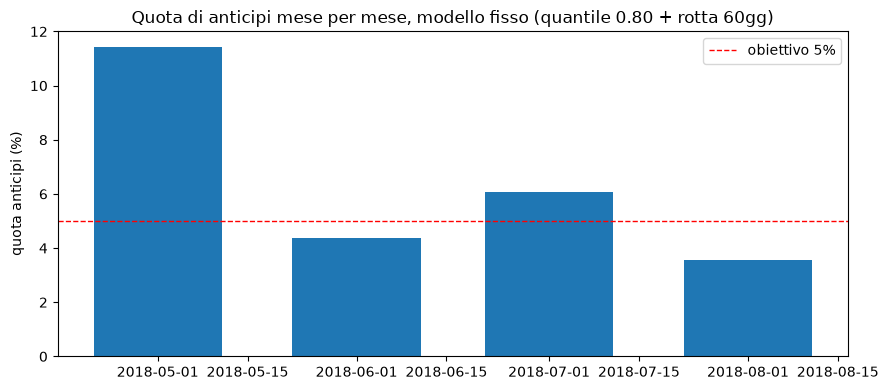

,n_ordini,MAE,anticipi_pct
mese,,,
2018-05-01,691,6.99,11.43
2018-06-01,6096,9.17,4.38
2018-07-01,6156,9.21,6.08
2018-08-01,6351,8.36,3.56


In [11]:
test_eval = test.copy()
test_eval['pred'] = winner.predict(test[cols])
test_eval['err'] = test_eval['pred'] - test_eval['delivery_days']
test_eval['mese'] = pd.to_datetime(test_eval['purchase_date']).dt.to_period('M').dt.to_timestamp()

per_mese = test_eval.groupby('mese').agg(
    n_ordini=('err', 'size'),
    MAE=('err', lambda s: s.abs().mean()),
    anticipi_pct=('err', lambda s: (s < 0).mean() * 100),
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(per_mese.index, per_mese['anticipi_pct'], width=20, color='tab:blue')
ax.axhline(5.0, color='red', linestyle='--', linewidth=1, label='obiettivo 5%')
ax.set_ylabel('quota anticipi (%)')
ax.set_title('Quota di anticipi mese per mese, modello fisso (quantile 0.80 + rotta 60gg)')
ax.legend()
fig.tight_layout()
plt.show()
per_mese.round(2)

## 7. Conclusioni

**Cosa ha funzionato**

| modello | MAE test | anticipi test |
|---|---|---|
| Baseline ufficiale | 13.13 | 5.3% |
| Sez. 9: MSE asimmetrica `penalty=5` | 10.00 | 4.4% |
| quantile `alpha=0.80` + rotta 90gg | 9.47 | 4.4% |
| **quantile `alpha=0.80` + rotta 60gg** | **8.84** | **4.9%** |

- **La quantile regression domina la MSE asimmetrica su tutta la frontiera.** Non e' solo piu'
  elegante: a parita' di quota di anticipi costa meno MAE. Ed elimina una griglia da tarare,
  perche' `quantile_alpha` ha un significato diretto ("quale percentile della distribuzione
  condizionale sto promettendo").
- **Le feature di rotta funzionano solo con la finestra mobile.** Con la media espandente
  *peggiorano* il modello (MAE 10.22 contro 9.57 senza rotta, a `alpha=0.80`): restano ancorate
  ai tempi lunghi del 2016-17 mentre i tempi reali calano. Con finestra a 60 giorni diventano il
  guadagno singolo piu' grande di tutto il lavoro (-1.16gg di MAE rispetto alla Sezione 9), e
  `route_prior_days` diventa la feature piu' importante del modello.
  La finestra e' quindi una scelta di design, non un dettaglio: **la stessa feature puo' aiutare
  o danneggiare a seconda di quanto passato incorpora.**
- Le finestre fra 21 e 60 giorni si equivalgono entro ~0.4gg (differenze molto sopra il rumore
  da seed, che e' ~0.01gg): 60gg e' la scelta migliore *nella zona sotto il 5%*, ma non c'e'
  motivo di inseguire il valore esatto.
- **Due trappole di misura incontrate qui, entrambe risolte cambiando metrica e non modello:**
  (1) per un modello quantile la permutation importance va calcolata con la *pinball loss*, non
  con il MAE, altrimenti esce con il segno sbagliato; (2) le tre feature con importance negativa
  non vanno buttate - l'ablazione mostra che toglierle lascia il modello sulla stessa frontiera,
  quindi l'importance negativa era un artefatto della correlazione fra rotta e distanza, non un
  invito a semplificare.

**Il limite da tenere presente**

La quota di anticipi misurata sul set di calibrazione (~11%) e quella sul test (~5%) divergono
per il drift gia' diagnosticato in Sezione 8. Vuol dire che:

- la scelta di `alpha` fatta oggi sara' sbagliata fra qualche mese, in una direzione o nell'altra;
- il confronto fra finestre e' stato fatto guardando il test, quindi il valore esatto (60gg) va
  preso come "una finestra corta", non come un ottimo trasferibile. La scelta *rolling contro
  espandente*, invece, e' motivata dal drift documentato e non dal test.

**In produzione:** rifare il fit e ri-scegliere `alpha` a cadenza mensile su una finestra recente,
monitorando la quota di anticipi realizzata (il grafico della Sezione 6 e' esattamente il
controllo da mettere in dashboard). Il segmento a lunga distanza / RJ-PA-PE individuato nel
notebook 03 resta quello da tenere d'occhio per primo.

**Prossimo passo suggerito:** pesare gli esempi di training per recency (`sample_weight` con
decadimento esponenziale sulla data di acquisto). E' la terza leva sullo stesso problema di
drift e agisce dove le altre due non arrivano, cioe' sul peso che il modello da' al 2016-17.